**BUILDING A MODEL TO RATE SENTIMENTS OF TWEETS ABOUT GOOGLE AND APPLE PRODUCTS**
Student Name: Stephen Jilani Project: Phase 3 Date:14 June 2026

**1. BUSINESS UNDERSTANDING**

A Kenyan company an is in a predicament on classifying Twitter sentiments on Google and Apple products. This is with the aim of knowing the perceptions of the products in question to the public. The company has an objective to build a classification models that will help them classify sentiments into positive/negative(binary classification) or positive/neutral/negative(multiclass classification).

**STAKEHOLDERS**

The stakeholder of the project is the Kenyan company at large, however, the specific persons of interest include but not limited to the following:

    1. Customer support.
    2. Product teams.
    3. Sales and marketing department.
    4. Research and development department.

**BUSINESS OBJECTIVES** The primary objective is to build a classification model on twitter reviews on Google and Apple products to better understand customer perception and improve decision making.

    1. Compare multiple models for binary sentiment classification.
    2. Evaluate model performance using F1 Score, precision, and recall.
    3. Provide insights on customer sentiment distribution.

**BUSINESS QUESTIONS**

    1. What are the main drivers of sentiment classification.
    2. What are the most common emotions expressed in reviews.
    3. Which model performs best for sentiment analysis.

**PROJECT SUCCESS METRICS**

This project is going to be a success if the metrics below are met:

    1. If it's possible to identify a binary model that yields the best F1-score, precision and recall.
    2. If it's possible that the multiclass classifier achieves an acceptable F1-score, precision and recall.

**2. DATA UNDERSTANDING**

The data was obtained from CriwdFlower via data.world, and is composed of sentiments which were rated by human raters as positive, negative or either in over 9,000 tweets. The sentiments are in relation to Apple and Google products.

Preliminary analysis on the data for better understanding of the data.

In [1]:
#Importation of necesarry libraries
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

C:\Users\USER\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\USER\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
#Loading the dataset
df = pd.read_csv('judge-1377884607_tweet_product_company.csv', encoding="latin1")
df.head()

,tweet_text,emotion_in_tweet_is_directed_at,is_there_an_emotion_directed_at_a_brand_or_product
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [3]:
#Checking descriptive statistics on the data
df.info()

#Observations
#The data has 3 columns and 9,003 rows. The colums are for the tweet text, the brand directed to and the sentiment classification. The columns will need
# renamed to make their names shorter.
#All the 3 columns are formated in text

<class 'pandas.DataFrame'>
RangeIndex: 9093 entries, 0 to 9092
Data columns (total 3 columns):
 #   Column                                              Non-Null Count  Dtype
---  ------                                              --------------  -----
 0   tweet_text                                          9092 non-null   str  
 1   emotion_in_tweet_is_directed_at                     3291 non-null   str  
 2   is_there_an_emotion_directed_at_a_brand_or_product  9093 non-null   str  
dtypes: str(3)
memory usage: 1.4 MB


In [4]:
#Checking the columns on brands and sentiments to see the unique entries there. The tweent column is expected to have unique entries.However, we will
#check just to be sure.

print(df['emotion_in_tweet_is_directed_at'].unique())
print(df['emotion_in_tweet_is_directed_at'].value_counts())
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].unique())
print(df['is_there_an_emotion_directed_at_a_brand_or_product'].value_counts())

#Observations
#The "brand column has quite a number of unique entries but from the results below. There is a possibility that the entries there can be transformed into
#either Apple or Google. The same can also be said about the "sentiment classification" column which has less unique items but all seem to be able to
#be classified as either Negative, Positive or Neutral via data cleaning.

<ArrowStringArray>
[                         'iPhone',              'iPad or iPhone App',
                            'iPad',                          'Google',
                               nan,                         'Android',
                           'Apple',                     'Android App',
 'Other Google product or service',  'Other Apple product or service']
Length: 10, dtype: str
emotion_in_tweet_is_directed_at
iPad                               946
Apple                              661
iPad or iPhone App                 470
Google                             430
iPhone                             297
Other Google product or service    293
Android App                         81
Android                             78
Other Apple product or service      35
Name: count, dtype: int64
<ArrowStringArray>
[                  'Negative emotion',                   'Positive emotion',
 'No emotion toward brand or product',                       'I can't tell']
Length: 4, dtype: str

**3. DATA CLEANING AND EXPLORATORY DATA ANALYSIS**

In [5]:
#Checking for blank columns in the dataset
df.isna().sum()

#Observation
#The tweet text has one blank row. This may have to be dropped as the lack of text measn there is nothing to be rated.
#The brand column has over 50% of blank rows and this is significant hence may need to be filled based on the condition of the tweet
#The emotion column has no  blank entries which is a good thing.

tweet_text                                               1
emotion_in_tweet_is_directed_at                       5802
is_there_an_emotion_directed_at_a_brand_or_product       0
dtype: int64

In [6]:
#Checking if the tweet text has any duplicates as this is expected to have unique entries only.
df['tweet_text'].duplicated().sum()
#This observation is an indication of possibility that there are reviews that were submitted twice. The possibility of having 2 people submiting an indentical review
#on a product arevery minimal. This will be sorted out by dropping the duplicates.

27

In [7]:
#Running the columns of the dataset to see them before renaming
df.columns

Index(['tweet_text', 'emotion_in_tweet_is_directed_at',
       'is_there_an_emotion_directed_at_a_brand_or_product'],
      dtype='str')

In [8]:
#Renaming the columns of the dataset and running the dataset to see if the names were replaced
new_columns = ['Tweet_text','Brand', 'Classification']
df.columns = new_columns
df.head()

,Tweet_text,Brand,Classification
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,iPhone,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,iPad or iPhone App,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,iPad,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,iPad or iPhone App,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


In [9]:
#The Tweet_text column has one blank row which will be dropped. We will also remove any white spaces or empty strings if any.
df = df.dropna(subset =['Tweet_text'])
df = df[df['Tweet_text'].str.strip() !=""]

In [10]:
#Printing info for the Tweet_text column to see if the rows have been dropped.
df['Tweet_text'].shape
#Observation
#The column initially had 9,003 rows but now 1 has been dropped.

(9092,)

In [11]:
# Dropping the duplicates in the tweet_text column. This is because they might be reviews which have been entered more than once as its almost
#impossible for2 people to give an identical review in form of a tweet.

df = df.drop_duplicates(subset = ['Tweet_text'])
df['Tweet_text'].shape

(9065,)

In [12]:
#We will now go to the classification column and ensure it's cleaned then we will go back to the tweet_text column later on.

df['Classification'].unique()

#The column has emotions like "I can't tell" and 'No emotion toward brand or product' which are the ones that can be considered as neutral.
#We will replace these strings with 'neutral"

<ArrowStringArray>
[                  'Negative emotion',                   'Positive emotion',
 'No emotion toward brand or product',                       'I can't tell']
Length: 4, dtype: str

In [13]:
df['Classification']= df['Classification'].replace({'No emotion toward brand or product':'Neutral emotion', "I can't tell":'Neutral emotion'})
df['Classification'].unique()

<ArrowStringArray>
['Negative emotion', 'Positive emotion', 'Neutral emotion']
Length: 3, dtype: str

In [14]:
#Checking if the tweet_text column contains keywords that can match to a specific brand
df[df['Brand'].isna()]['Tweet_text'].head(20)

#Observation
#It can be noted that there are words like iPad, Google, App Store, iTunes which can be used to determine which brand a tweet is associated with.

5     @teachntech00 New iPad Apps For #SpeechTherapy...
16    Holler Gram for iPad on the iTunes App Store -...
32    Attn: All  #SXSW frineds, @mention Register fo...
33        Anyone at  #sxsw want to sell their old iPad?
34    Anyone at  #SXSW who bought the new iPad want ...
35    At #sxsw.  Oooh. RT @mention Google to Launch ...
37    SPIN Play - a new concept in music discovery f...
39    VatorNews - Google And Apple Force Print Media...
41    HootSuite - HootSuite Mobile for #SXSW ~ Updat...
42    Hey #SXSW - How long do you think it takes us ...
43    Mashable! - The iPad 2 Takes Over SXSW [VIDEO]...
44    For I-Pad ?RT @mention New #UberSocial for #iP...
46    Hand-Held Û÷HoboÛª: Drafthouse launches Û÷H...
48    Orly....? ÛÏ@mention Google set to launch new...
50    Khoi Vinh (@mention says Conde Nast's headlong...
51    ÛÏ@mention {link} &lt;-- HELP ME FORWARD THIS...
52    ÷¼ WHAT? ÷_ {link} ã_ #edchat #musedchat #s...
53    .@mention @mention on the location-based '

In [15]:
# For filling the null values in our brand column, we will lower the text in the tweet_text column and use key words to fill the missing values.
keywords_apple = [
    'apple', 'iphone', 'ipad', 'macbook', 'ios',
    'itunes', 'safari', 'icloud', 'ipod', 'app store'
]

keywords_google = [
    'google', 'android', 'gmail', 'youtube',
    'chrome', 'google maps', 'pixel', 'nexus'
]

def refer_brand(text):
    text = str(text).lower()

    apple = any(word in text for word in keywords_apple)
    google = any(word in text for word in keywords_google)

    if apple and google:
        return 'Both'
    elif apple:
        return 'Apple'
    elif google:
        return 'Google'
    else:
        return None

null_brands = df['Brand'].isna()
df.loc[null_brands, 'Brand'] = df.loc[null_brands, 'Tweet_text'].apply(refer_brand)


In [16]:
#Seeing if the code above has worked by checking how many null values are after running the code above.
df['Brand'].isna().sum()

#Observation
#The null rowshave reduced from 5,000 to 700 meaning that we have filled a bigger percentage of the null rows. Next we will see the unique values in
#the column now to see if we have something to drop. It's essential that we drop the remaining 700 null rows in the brand column.

702

In [17]:
#Checking unique entries in the brand column
df['Brand'].unique()

#Based on the output, there needs standardization in the brand column so that we can only have google or apple as our unique entries

<ArrowStringArray>
[                         'iPhone',              'iPad or iPhone App',
                            'iPad',                          'Google',
                           'Apple',                         'Android',
                     'Android App', 'Other Google product or service',
                            'Both',                               nan,
  'Other Apple product or service']
Length: 11, dtype: str

In [18]:
#Ensuring that there is standardization in the column to Google and Apple only

df['Brand']= df['Brand'].replace({'iPhone':'Apple', "iPad or iPhone App":'Apple', 'iPad':'Apple','Android':'Google','Android App':'Google','Other Google product or service':'Google','Other Apple product or service':'Apple'})
df['Brand'].unique()
#Observation
#The rows which have both do not direct us to any specific brand hence do not add any relevance to our to be classification model. The same applies to
#the null values even after filling them. These will be dropped.

<ArrowStringArray>
['Apple', 'Google', 'Both', nan]
Length: 4, dtype: str

In [19]:
#Dropping all the blank rows in the 'Brand' column and those that have both Google and Apple as they are not relevant to our classificaition problem.

df = df.dropna(subset = ['Brand'])
df= df[~df['Brand'].isin(['Both'])]
print(df['Brand'].unique())
print(df['Brand'].shape)
     

<ArrowStringArray>
['Apple', 'Google']
Length: 2, dtype: str
(8154,)


**EXPLORATORY DATA ANALYSIS ON NON-TEXT COLUMNS**
The none-text columns here are the Beand and Classification columns

In [20]:
#Running the dataset for visibility
df.head()

,Tweet_text,Brand,Classification
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Apple,Negative emotion
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple,Positive emotion
2,@swonderlin Can not wait for #iPad 2 also. The...,Apple,Positive emotion
3,@sxsw I hope this year's festival isn't as cra...,Apple,Negative emotion
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion


**UNIVARIATE ANALYSIS ON NON-TEXT COLUMNS**

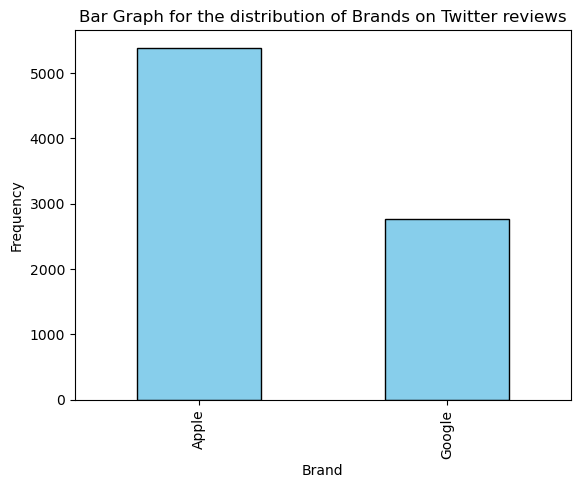

In [21]:
#Plotting a bar graph to show the frequency distribution between Google and Apple brands in the Brand column

brand_names = df['Brand'].value_counts()

brand_names.plot(kind = 'bar', color= 'skyblue', edgecolor = 'black')
plt.xlabel('Brand')
plt.ylabel('Frequency')
plt.title('Bar Graph for the distribution of Brands on Twitter reviews')
plt.show()

The bar graph shows that Apple products get more revieews compared to the Google products. This may lead to a bias problem in the model. However, a ratio of less that 1:2 is manageable.

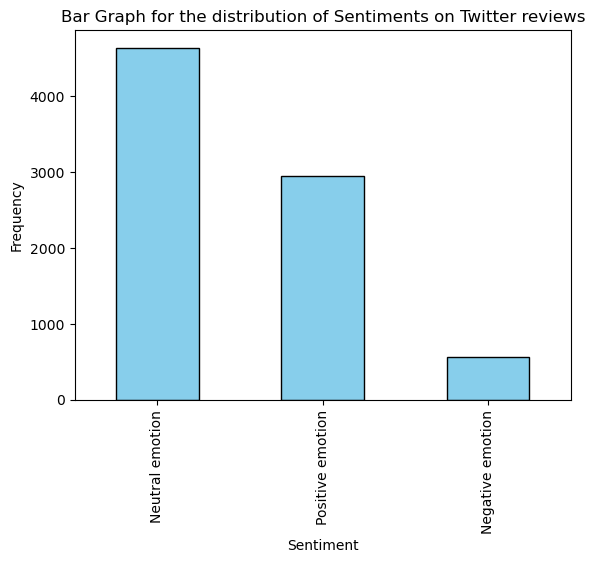

In [22]:
#Plotting a bar graph to show the frequency distribution between Negative, Positive and Neutral reviews

sentiment_class = df['Classification'].value_counts()

sentiment_class.plot(kind = 'bar', color= 'skyblue', edgecolor = 'black')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.title('Bar Graph for the distribution of Sentiments on Twitter reviews')
plt.show()

The bar graph shows that neutral emotions are the majority in the dataset, followed by positive and then negative emotions. This may be an indication that Twitter users are quite indifferent when it comes to choosing either Google or Apple products.

**BIVARIATE ANALYSIS ON NON-TEXT COLUMNS**

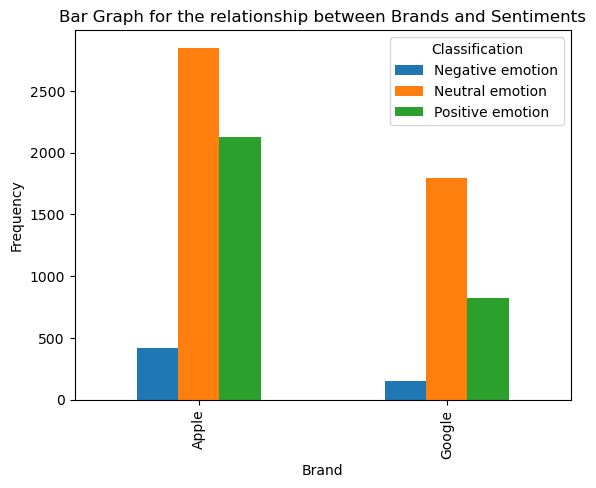

In [23]:
#Plotting a clustered bar graph on the Brand and Classification column

brand_class = pd.crosstab(
    df['Brand'],
    df['Classification']
)

brand_class.plot(kind = 'bar')#, figsize=(8,5), edgecolor='black')
plt.xlabel('Brand')
plt.ylabel('Frequency')
plt.title('Bar Graph for the relationship between Brands and Sentiments')
plt.show()

The graph above shows that Apple products are more talked about compared to google products. This is evident in Apple products having more frequency in the dataset. However, the most sentiments are the neutral ones meaning that most reviewers are indifferent on the products they use.

Negative emotions are generally the lowest across the dataset as well.

**TEXT PREPROCESSING**
This section is meant to prepare the tweet_text column for analysis and modelling

In [24]:
#Importing NLP libraries not already imported above
import nltk
import string


In [25]:
nltk.download('punkt') # for tokenization
nltk.download('stopwords') # for removing stopwords
nltk.download('wordnet')   # for lemmatization

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [26]:
from nltk.stem import PorterStemmer

In [27]:
#Cleaning and preprocessing of the tweet_text column.

def preprocess(text):
    #lowercase
    text = text.lower()
    #removing mentions
    text =re.sub(r'[@＠]\s*\w+', '', text)
    #removing URLs
    text = re.sub(r'http\S+', '', text)
    #tokenization
    tokens = nltk.word_tokenize(text)
    #removing punctuaton and numbers
    tokens = (word for word in tokens if word.isalpha())
    #removing stopwords
    stop_words = set(stopwords.words('english'))
    tokens = (word for word in tokens if word not in stop_words)
    #lematization
    lemma = WordNetLemmatizer()
    tokens = [lemma.lemmatize(word) for word in tokens]
    #stemming
    stemma = PorterStemmer()
    tokens = [stemma.stem(word) for word in tokens]
    return ' '.join(tokens)

In [28]:
#Applying the results of the code above into our original dataset df

df['clean_text'] = df['Tweet_text'].apply(preprocess)
df.head()

,Tweet_text,Brand,Classification,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Apple,Negative emotion,iphon hr tweet dead need upgrad plugin station...
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple,Positive emotion,know awesom app like appreci design also give ...
2,@swonderlin Can not wait for #iPad 2 also. The...,Apple,Positive emotion,wait ipad also sale sxsw
3,@sxsw I hope this year's festival isn't as cra...,Apple,Negative emotion,hope year festiv crashi year iphon app sxsw
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri sxsw marissa mayer googl tim t...


**EXPLORATORY DATA ANALYSIS ON TEXT COLUMN**

In [29]:
#Checking for frequent words and vizualiting them as well.
#Importing the counter

from collections import Counter

frequent_words = " ".join(df['clean_text']).split()
word_counts = Counter(frequent_words).most_common(20)

word_df = pd.DataFrame(word_counts, columns=['word', 'count'])

#The dataset contains a lot of social media noisy text like 'rt', 'link', 'sxsw' etc which adds noise in our dataset and may affect how our model learns.
#We will create a custom stop words list and remove these words
#The stemming applied was also aggressive such that words like 'Apple' have been reduced to 'Appl' as seen below or google reduced to 'googl'. These need
#to be restored.

Text(0.5, 1.0, 'Top 20 Most Frequent Words')

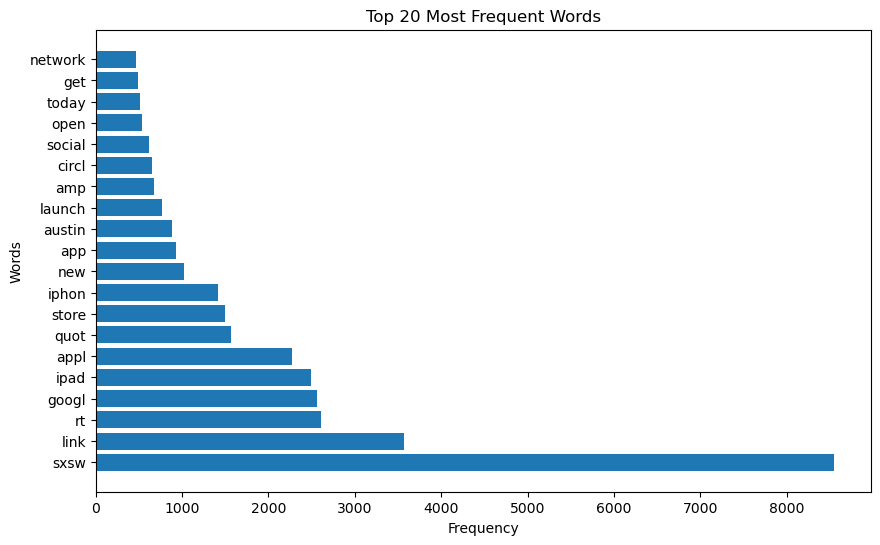

In [30]:
#Vizualizing the results of the frequent words
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(word_df['word'], word_df['count'])

plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top 20 Most Frequent Words')

In [31]:
#creating a custom stop words list
twitter_noise = ['rt', 'link', 'amp', 'quot', 'sxsw']

#Removing the custom stop words
df['clean_text'] = df['clean_text'].apply(
    lambda x: " ".join([word for word in x.split() if word not in twitter_noise])
)

In [32]:
#Restoring apple key words that have been destroyed by stemming
df['clean_text'] = df['clean_text'].str.replace('appl', 'apple', regex=False)
df['clean_text'] = df['clean_text'].str.replace('iphon', 'iphone', regex=False)
df['clean_text'] = df['clean_text'].str.replace('googl', 'google', regex=False)

In [33]:
print(df['clean_text'].str.contains('googl').sum())
print(df['clean_text'].str.contains('iphon').sum())
print(df['clean_text'].str.contains('appl').sum())

#The number of times these words appear has reduced meaning that they have been replaced

2370
1383
2092


In [34]:
#Using N-grams to capture phrases and not single words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)
phrases = vectorizer.fit_transform(df['clean_text'])

ngrams = (vectorizer.get_feature_names_out())
counts = phrases.toarray().sum(axis=0)

ngram_df = pd.DataFrame({
    'ngram':ngrams,
    'count':counts
}).sort_values(by='count',ascending=False)

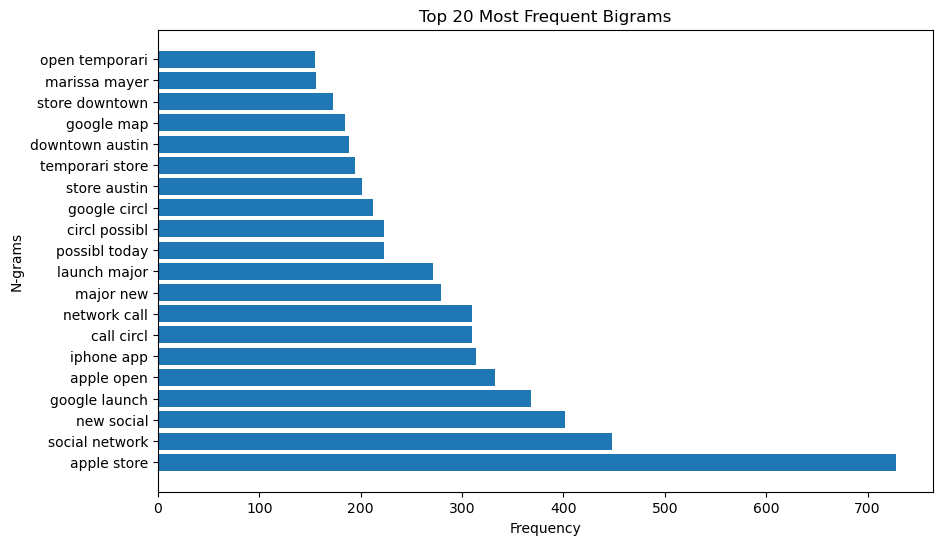

In [35]:
#vizualizing the contents of the most common phrases

plt.figure(figsize=(10,6))

plt.barh(
    ngram_df['ngram'],
    ngram_df['count']
)

plt.xlabel('Frequency')
plt.ylabel('N-grams')
plt.title('Top 20 Most Frequent Bigrams')
plt.show()

**4. DATA PREPARATION**

The intention is to do binary and multiclass classifiers. Therefore, we will save 2 datasets; one for the binary classification and the other one for the multiclass classifier.

In [36]:
df['Classification'].unique()

<ArrowStringArray>
['Negative emotion', 'Positive emotion', 'Neutral emotion']
Length: 3, dtype: str

In [37]:
#Dropping the neutral emotion so that we can have only the positive and negative emotions in the column and viewing the results. Thisis going to be the dataset
#for binary classification
df_binary = df[df['Classification'] != 'Neutral emotion'].copy()
print(df_binary['Classification'].unique())
print(df_binary.head())

<ArrowStringArray>
['Negative emotion', 'Positive emotion']
Length: 2, dtype: str
                                          Tweet_text   Brand  \
0  .@wesley83 I have a 3G iPhone. After 3 hrs twe...   Apple   
1  @jessedee Know about @fludapp ? Awesome iPad/i...   Apple   
2  @swonderlin Can not wait for #iPad 2 also. The...   Apple   
3  @sxsw I hope this year's festival isn't as cra...   Apple   
4  @sxtxstate great stuff on Fri #SXSW: Marissa M...  Google   

     Classification                                         clean_text  
0  Negative emotion    iphone hr tweet dead need upgrad plugin station  
1  Positive emotion  know awesom app like appreci design also give ...  
2  Positive emotion                                wait ipad also sale  
3  Negative emotion            hope year festiv crashi year iphone app  
4  Positive emotion  great stuff fri marissa mayer google tim tech ...  


In [38]:
df_multi = df.copy()
df_multi.head()

#This is going to the dataset for multiclass classifier

,Tweet_text,Brand,Classification,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Apple,Negative emotion,iphone hr tweet dead need upgrad plugin station
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple,Positive emotion,know awesom app like appreci design also give ...
2,@swonderlin Can not wait for #iPad 2 also. The...,Apple,Positive emotion,wait ipad also sale
3,@sxsw I hope this year's festival isn't as cra...,Apple,Negative emotion,hope year festiv crashi year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim tech ...


In [39]:
#Splitting my data for the binary classification into X and Y. The feature is going to be the 'clean text' column and the target will be the
#'classification'

X_train,X_test, y_train, y_test = train_test_split(
    df_binary['clean_text'],
    df_binary['Classification'],
    test_size = 0.2,
    random_state = 42,
    stratify = df_binary['Classification']
)

In [40]:
#Feature engineering using TF-IDF. This is to convert the text data into numerical format
vectorize =TfidfVectorizer()
X_train_vec = vectorize.fit_transform(X_train)
X_test_vec = vectorize.transform(X_test)

**5. MODELLING AND MODEL EVALUATION**

In [41]:
#Logistic regression as the base model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_vec, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [42]:
#Making predictions with the base model
y_pred_log = log_model.predict(X_test_vec)

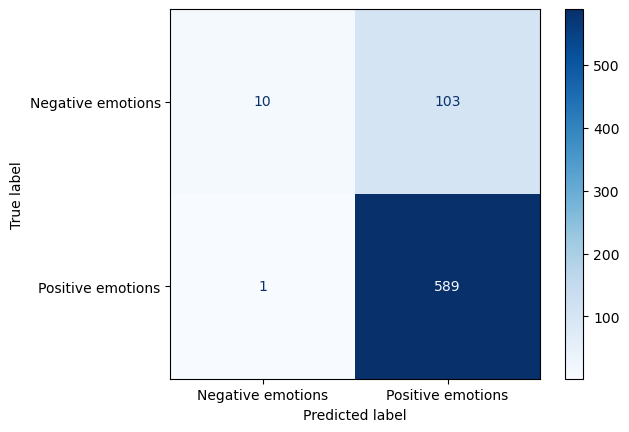

                  precision    recall  f1-score   support

Negative emotion       0.91      0.09      0.16       113
Positive emotion       0.85      1.00      0.92       590

        accuracy                           0.85       703
       macro avg       0.88      0.54      0.54       703
    weighted avg       0.86      0.85      0.80       703



In [43]:
#Model Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=["Negative emotions", "Positive emotions"])
display.plot(cmap=plt.cm.Blues)
plt.show()

print(classification_report(y_test, y_pred_log))

**Confusion matrix interpretation**

The model achieved a precision of 0.91, a recall of 0.09, f1-score of 0.16 on the negative emotions. The precision was 0.85, recall of 1.00 and f1 score of 0.92 for the positive emotions. This is however our base model and will be used for comparison purposes with the models explored below.

In [44]:
#Second model is the random forests

#Importation of libary
from sklearn.ensemble import RandomForestClassifier

#Fitting of the model

rand_forest = RandomForestClassifier(n_estimators=100, random_state=7)
rand_forest.fit(X_train_vec, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

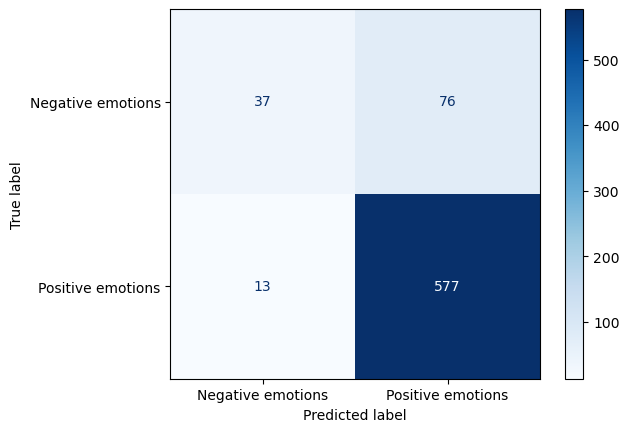

                  precision    recall  f1-score   support

Negative emotion       0.74      0.33      0.45       113
Positive emotion       0.88      0.98      0.93       590

        accuracy                           0.87       703
       macro avg       0.81      0.65      0.69       703
    weighted avg       0.86      0.87      0.85       703



In [45]:
#Making predictions using the Random Forest Model Above and model evaluation

y_pred_rand_forest = rand_forest.predict(X_test_vec)

#Running confusion matrix on our model
cm_rand_forest = confusion_matrix(y_test, y_pred_rand_forest)

display_rand_forest = ConfusionMatrixDisplay(confusion_matrix = cm_rand_forest, display_labels=["Negative emotions", "Positive emotions"])
display_rand_forest.plot(cmap=plt.cm.Blues)
plt.show()
#Running the classification report for the model
print(classification_report(y_test, y_pred_rand_forest))

**Confusion matrix interpretation**

The RandomForest model led to improvements compared to the Logistic Regression model. This was due to the increase in recall from 0.09 to 0.33, F1-score from 0.16 to 0.45 for negative emotions. For positive emotions, the precision increased from 0.85 to 0.88, recall reduced from 1.0 to 0.98 and f1 score increased from 0.92 to 0.93

In [46]:
#Hyper parameter tuning for Random Forest

from sklearn.model_selection import GridSearchCV

#Instantiating the classifier
r_forest = RandomForestClassifier(random_state=7)

parameter_grid = {
    'n_estimators': [50, 100, 200, 300, 500]
}
#Fitting GridSearch

grid_search = GridSearchCV(
    estimator=r_forest,
    param_grid=parameter_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_search.fit(X_train_vec, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [47]:
#Printing the results of hyperparameter tuning
print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'n_estimators': 300}
Best CV score: 0.8491803956008257


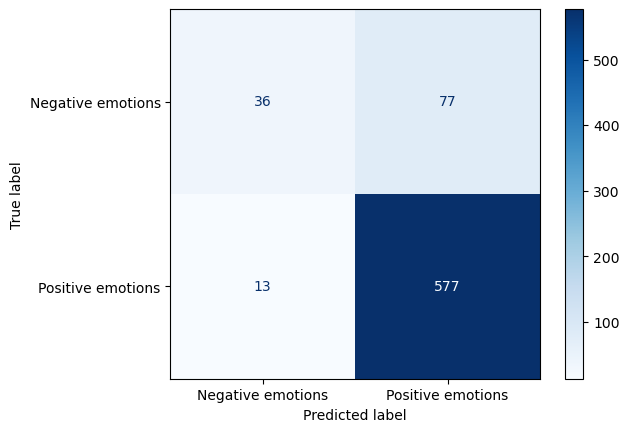

                  precision    recall  f1-score   support

Negative emotion       0.73      0.32      0.44       113
Positive emotion       0.88      0.98      0.93       590

        accuracy                           0.87       703
       macro avg       0.81      0.65      0.69       703
    weighted avg       0.86      0.87      0.85       703



In [48]:
#Evaluation of the best model

best_rand_forest = grid_search.best_estimator_

y_pred_rand_forest_tuned = best_rand_forest.predict(X_test_vec)


#Running confusion matrix and classification report
cm_rand_forest_tuned = confusion_matrix(y_test, y_pred_rand_forest_tuned)

display_rand_forest_tuned = ConfusionMatrixDisplay(confusion_matrix = cm_rand_forest_tuned, display_labels=["Negative emotions", "Positive emotions"])
display_rand_forest_tuned.plot(cmap=plt.cm.Blues)
plt.show()
print(classification_report(y_test, y_pred_rand_forest_tuned))

**Confusion matrix interpretation**

The model performance on the tuned Random Forest reduced significantly, this is to say that the base model RandomForest was already at a good step in balancing between bias and variance in the dataset, such that tuning just moved the model away from this balance.

In [49]:
#Installing XGBoost

!pip install xgboost

In [50]:
#Third model XG Boost

#Importation of libraries amd fitting of the model
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

model_XGBoost = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
model_XGBoost.fit(X_train_vec, y_train_encoded)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


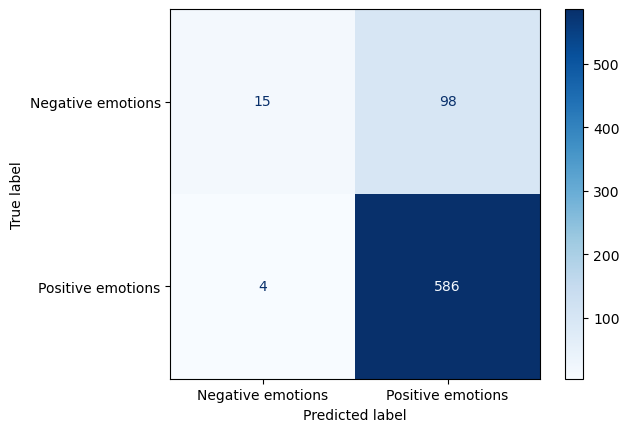

              precision    recall  f1-score   support

           0       0.79      0.13      0.23       113
           1       0.86      0.99      0.92       590

    accuracy                           0.85       703
   macro avg       0.82      0.56      0.57       703
weighted avg       0.85      0.85      0.81       703



In [51]:
# Making predictions and evaluation of the model

y_pred_XGBoost = model_XGBoost.predict(X_test_vec)


cm_XGBoost = confusion_matrix(y_test_encoded, y_pred_XGBoost)

display_XG_Boost = ConfusionMatrixDisplay(confusion_matrix = cm_XGBoost, display_labels=["Negative emotions", "Positive emotions"])
display_XG_Boost.plot(cmap=plt.cm.Blues)
plt.show()
#Running the classification report for the model
print(classification_report(y_test_encoded, y_pred_XGBoost))

**Confusion matrix interpretation**

This model will be compared to the base RandomForest model as the tuned model took the model off-balance. This model has generally led to improvements in the precision from 0.74 to 0.79, the recall rate has reduced from 0.33 to 0.13. However, the f1 score has increased from 0.93 to 0.93. This is a considerable improvement hence making XG Boost the best model so far.

In [52]:
#Hyper paramater tuning for XGBoost

#Instantiating the classifier
xgb_tuned = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

#Listing of parameters
parameter_grid_XG = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
}

#Instantiating GridSearch
grid_search_XG = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=parameter_grid_XG,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

#Fitting the model
grid_search_XG.fit(X_train_vec, y_train_encoded)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:36:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_dig

In [53]:
#Printing the best parameters for the model

print("Best Parameters:", grid_search_XG.best_params_)
print("Best CV Score:", grid_search_XG.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Score: 0.8298656188696908


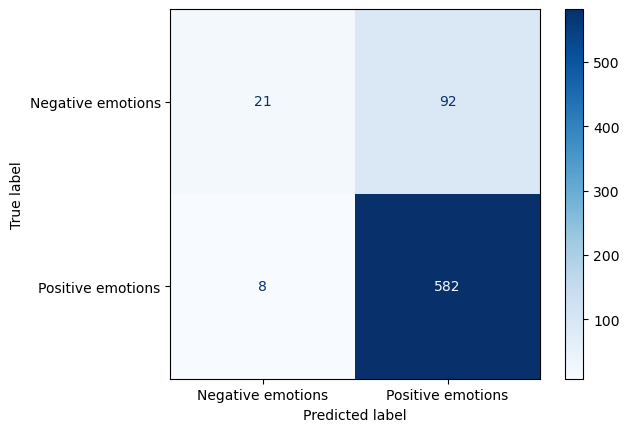

              precision    recall  f1-score   support

           0       0.72      0.19      0.30       113
           1       0.86      0.99      0.92       590

    accuracy                           0.86       703
   macro avg       0.79      0.59      0.61       703
weighted avg       0.84      0.86      0.82       703



In [54]:
#Making predictions with the best parameters and evaluating the model.

best_XG = grid_search_XG.best_estimator_

y_pred_XG_tuned = best_XG.predict(X_test_vec)

cm_XG_tuned = confusion_matrix(y_test_encoded,y_pred_XG_tuned)

display_XG_tuned = ConfusionMatrixDisplay(confusion_matrix = cm_XG_tuned, display_labels=["Negative emotions", "Positive emotions"])
display_XG_tuned.plot(cmap=plt.cm.Blues)
plt.show()
print(classification_report(y_test_encoded, y_pred_XG_tuned))

**Confusion matrix interpretation**

The tuned XG Boost has led to reduction in precision from 0.79 to 0.72, recall has improved from 0.13 to 0.19 while f1 score has also increased from 0.23 to 0.30 for negative emotions. For positive emotions, the precision, recall and f1 score have not changed at 0.86, 0.99 and 0.92 respectively. However, 2 out of the 3 metrics above have improved hence the tuned XG Boost model becomes the best out of all binary classification models explored.

In [55]:
#Model interpretability for XG Boost

feature_importance =pd.DataFrame({
    'feature':vectorize.get_feature_names_out(),
    'importance': best_XG.feature_importances_
}).sort_values('importance', ascending =False)

#Viewing the most important words
feature_importance.head(20)

,feature,importance
1540,headach,0.020152
1179,fascist,0.019959
1160,fail,0.016069
2241,need,0.015368
1159,fade,0.015062
2178,money,0.013630
283,batteri,0.012775
3820,yet,0.012619
3728,win,0.011640
1529,hate,0.011214


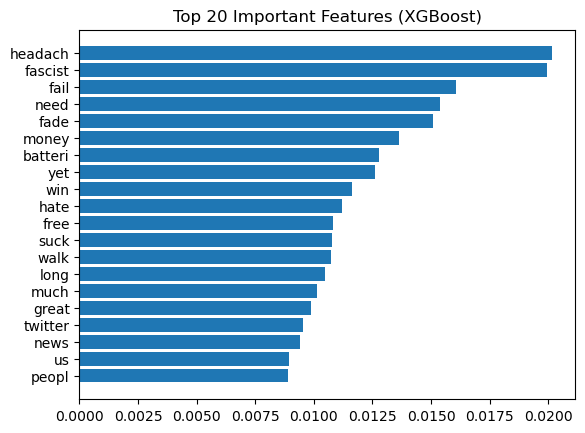

In [56]:
#Vizualization of feature importance above

top_features = feature_importance.head(20)

plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features (XGBoost)")
plt.show()

**Interpretation of key features**

There are words like 'headache', 'fail', 'hate', 'suck' which are the biggets drivers of negative emotion. On the other hand, there are words like 'win', 'great', 'free' which are the bigets drivers of positive emotion. There are words that do not reallly indicate any sentiment like battery, twitter etc which cannot be traced to a particular sentiment.

In [57]:
#Running the multiclass dataset for visibility
df_multi.head()

,Tweet_text,Brand,Classification,clean_text
0,.@wesley83 I have a 3G iPhone. After 3 hrs twe...,Apple,Negative emotion,iphone hr tweet dead need upgrad plugin station
1,@jessedee Know about @fludapp ? Awesome iPad/i...,Apple,Positive emotion,know awesom app like appreci design also give ...
2,@swonderlin Can not wait for #iPad 2 also. The...,Apple,Positive emotion,wait ipad also sale
3,@sxsw I hope this year's festival isn't as cra...,Apple,Negative emotion,hope year festiv crashi year iphone app
4,@sxtxstate great stuff on Fri #SXSW: Marissa M...,Google,Positive emotion,great stuff fri marissa mayer google tim tech ...


In [58]:
#Multiclass Classifier Using XGBoost

#Splitting my data for the multiclass classification into X and Y. The feature is going to be the 'clean text' column and the target will be the
#'classification'

Xm_train,Xm_test, ym_train, ym_test = train_test_split(
    df_multi['clean_text'],
    df_multi['Classification'],
    test_size = 0.2,
    random_state = 42,
    stratify = df_multi['Classification']
)

In [59]:
#Feature engineering using TF-IDF. This is to convert the text data into numerical format
vectorize_multi =TfidfVectorizer()
Xm_train_vec_multi = vectorize_multi.fit_transform(Xm_train)
Xm_test_vec_multi = vectorize_multi.transform(Xm_test)

In [60]:
#Fitting the multiclass model

label_encoder_multi = LabelEncoder()

ym_train_encoded_multi = label_encoder_multi.fit_transform(ym_train)
ym_test_encoded_multi = label_encoder_multi.transform(ym_test)

model_XGBoost_multi = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5)
model_XGBoost_multi.fit(Xm_train_vec_multi, ym_train_encoded_multi)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

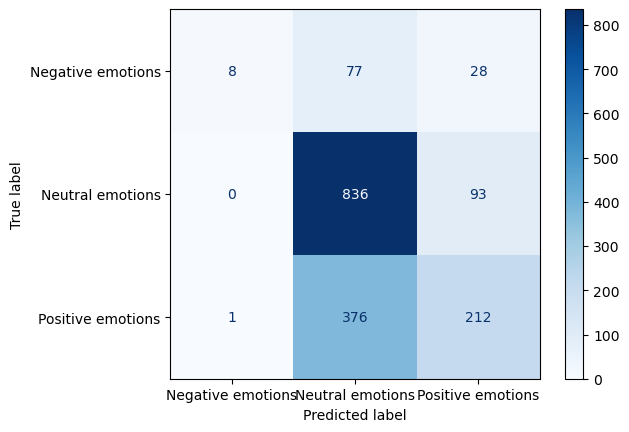

              precision    recall  f1-score   support

           0       0.89      0.07      0.13       113
           1       0.65      0.90      0.75       929
           2       0.64      0.36      0.46       589

    accuracy                           0.65      1631
   macro avg       0.72      0.44      0.45      1631
weighted avg       0.66      0.65      0.60      1631



In [61]:
#Making predictions and evaluation
y_pred_XGBoost_multi = model_XGBoost_multi.predict(Xm_test_vec_multi)


cm_XGBoost_multi = confusion_matrix(ym_test_encoded_multi, y_pred_XGBoost_multi)

display_XG_Boost_multi = ConfusionMatrixDisplay(confusion_matrix = cm_XGBoost_multi, display_labels=["Negative emotions","Neutral emotions", "Positive emotions"])
display_XG_Boost_multi.plot(cmap=plt.cm.Blues)
plt.show()
#Running the classification report for the model
print(classification_report(ym_test_encoded_multi, y_pred_XGBoost_multi))

**Confusion matrix interpretation**

The model achieved precision of 0.89, 0.65 and 0.64 on Negative, Neutral and Positive emotions respectively; recall of 0.07, 0.90 and 0.36 respectively and f1-score of 0.13, 0.75 and 0.46 respectively. This is going to be the basis for comparison with the tuned model below to choose which is the best for the multiclass classification.

In [62]:
#Hyper paramater tuning for XGBoost for Multiclass Classification

#Instantiate the classifier
xgb_multi_tuned = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

#Listing parameters
parameter_grid_XG_multi = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
}

#Instantiating GridSearch
grid_search_XG_multi = GridSearchCV(
    estimator=xgb_multi_tuned,
    param_grid=parameter_grid_XG_multi,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

#Fitting the model
grid_search_XG_multi.fit(Xm_train_vec_multi, ym_train_encoded_multi)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


C:\Users\USER\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:37:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1], 'max_depth': [3, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_dig

In [63]:
#Printing the best parameters for the model

print("Best Parameters:", grid_search_XG_multi.best_params_)
print("Best CV Score:", grid_search_XG_multi.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV Score: 0.6088512391068199


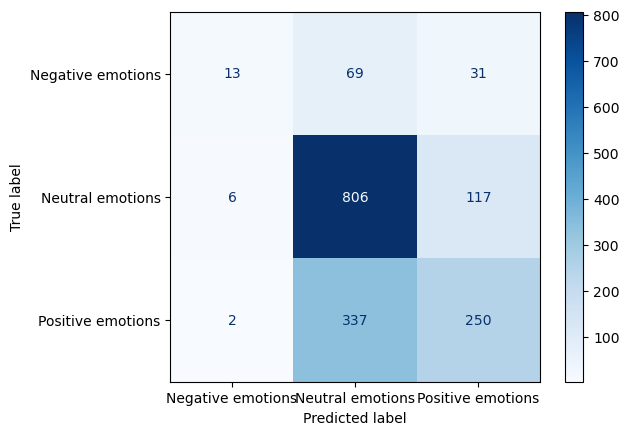

              precision    recall  f1-score   support

           0       0.62      0.12      0.19       113
           1       0.67      0.87      0.75       929
           2       0.63      0.42      0.51       589

    accuracy                           0.66      1631
   macro avg       0.64      0.47      0.48      1631
weighted avg       0.65      0.66      0.63      1631



In [64]:
#Making predictions with the best parameters and  model evaluation

best_XG_multi = grid_search_XG_multi.best_estimator_

ym_pred_XG_tuned_multi = best_XG_multi.predict(Xm_test_vec_multi)

cm_XG_tuned_multi = confusion_matrix(ym_test_encoded_multi,ym_pred_XG_tuned_multi)

display_XG_tuned_multi = ConfusionMatrixDisplay(confusion_matrix = cm_XG_tuned_multi, display_labels=["Negative emotions","Neutral emotions", "Positive emotions"])
display_XG_tuned_multi.plot(cmap=plt.cm.Blues)
plt.show()
print(classification_report(ym_test_encoded_multi, ym_pred_XG_tuned_multi))

**Confusion Matrix Interpretation**

There was a reduction in precision for Negative emotions, an increase for Neutral and Positive emotions. In recall, there was an increase in Negative emotions, a reduction in Neutral emotions and an increase in Positive emotions. For f1-score, there was an increase for Negative emotions, nochange forNeutral Emotions and an increase for Positive emotions. Generally, this model performed better than the base model for MultiClass classification hence making it the better model.

In [65]:
#Model interpretability for XG Boost Multi Class Classification

feature_importance_multi =pd.DataFrame({
    'feature':vectorize_multi.get_feature_names_out(),
    'importance': best_XG_multi.feature_importances_
}).sort_values('importance', ascending =False)

#Viewing the most important words
feature_importance_multi.head(20)

,feature,importance
1064,cool,0.011219
358,awesom,0.009377
2986,love,0.007953
1732,fade,0.007560
1759,fascist,0.006971
464,begin,0.006967
5034,thank,0.006752
2162,great,0.006562
4302,save,0.006325
1733,fail,0.006000


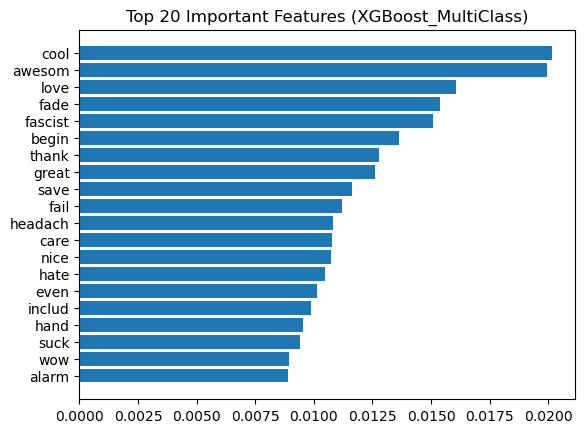

In [66]:
#Vizualization of feature importance above

top_features_multi = feature_importance_multi.head(20)

plt.barh(top_features_multi["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features (XGBoost_MultiClass)")
plt.show()

**Interpretation of Key features**

Words like cool, awesome, love, great have been the best drivers in the positive emotions category. Words like hate, fail, suck have been the biggest drivers in the Negative emotion category. There are words that cannot be assigned to a specific category like even, hand, begin which should be thedrivers for the neutral category.

**6. FINAL MODEL SELECTION**

**i. Binary Classification**

Based on the models above and the insights on each one of them, the best model is the tuned XGBoost Model which achieved an improvement in recall and f1 score for Negative emotions. On the other hand, precision, recall and f1 score maintained at te level with its base model. This generally led to an improvement in the performance of the model hance making it the best model.


**ii. Multiclass Classification**

Multicalass classification was done on XGBoost only with a base and a tuned model. There was a reduction in precision for Negative emotions, an increase for Neutral and Positive emotions. In recall, there was an increase in Negative emotions, a reduction in Neutral emotions and an increase in Positive emotions. For f1-score, there was an increase for Negative emotions, nochange for Neutral Emotions and an increase for Positive emotions. Generally, this model performed better than the base model for MultiClass classification hence making it the better model.

**7. RECOMMENDATIONS AND LIMITATIONS**

**BUSINESS RECOMMENDATIONS**

1. The stakeholders should implement the best models in the classification of review sentiments
2. The stakeholders need to analys top features that drive negative emotions like headache, suck, hate and identify what exactly lead to such sentiments.
3. The stakeholders should focus more on negative sentiments and route them to customer support and product teams

**EXPECTED IMPACT**

1. Improved customer satisfaction.
2. Understading of product perception in customers

**LIMITATIONS**

1. Class imbalance in the dataset may influence the performance of the model as the data contains very few negatives and a majority of neutral sentiments.
2. The data was social media noisy and that may affect the performance of the model
3. The data may be from a specific region in the world and may not be fit for the stakeholder’s region